## <center><font color=navy>Data Science for Quantitative Finance</font></center>
### <center>Reinforcement Learning for Portfolio Optimization</center>
### <center> Ali Habibnia</center>

    
<center> Assistant Professor, Department of Economics, </center>
<center> and Division of Computational Modeling & Data Analytics at Virginia Tech</center>
 <center> habibnia@vt.edu </center> 

### Suggested Readings

[Foundations of Reinforcement Learning with Applications in Finance](https://stanford.edu/~ashlearn/RLForFinanceBook/book.pdf) Ashwin Rao, Tikhon Jelvis

[Optimizing Portfolio with Two-Sided Transactions and Lending: A Reinforcement Learning Framework](https://arxiv.org/abs/2408.05382) Ali Habibnia, Mahdi Soltanzadeh

---

Reinforcement Learning (RL) provides a **flexible and adaptive framework** for solving financial portfolio optimization problems in environments characterized by **uncertainty**, **non-stationarity**, and **partial observability**.

Unlike traditional portfolio theory (e.g., Markowitz's mean-variance framework), which assumes static optimization with known return distributions, RL allows an agent to **continuously learn and adapt** its investment policy based on experience and feedback from the market.

### Why RL is Well-Suited for Finance

- **Sequential nature**: Markets evolve over time; RL naturally models decisions over time horizons.
- **Adaptivity**: RL agents update their policies continuously in response to changing regimes and patterns.
- **Exploration**: RL can discover non-obvious strategies that static models may miss.
- **Black-box environments**: RL does not require explicit modeling of asset dynamics — it learns from experience.


This notebook introduces the theoretical and practical foundations of Reinforcement Learning (RL) and its application to portfolio optimization.

---

## What is Reinforcement Learning?

Reinforcement Learning (RL) is a subfield of machine learning that focuses on how agents should take actions in an environment in order to maximize some notion of cumulative reward over time.

Unlike supervised learning, where the model learns from a labeled dataset (input-output pairs), RL involves learning from **sequential interaction** with the environment. The agent receives feedback only in the form of **scalar rewards**, which may be **delayed**, **noisy**, or **sparse**.

### Core Characteristics of RL:
- **Sequential decision-making**: The agent makes decisions over multiple time steps.
- **Exploration vs. Exploitation**: The agent must explore new actions to discover their outcomes while exploiting known good actions to maximize reward.
- **Delayed rewards**: Actions may affect not only immediate rewards but also long-term outcomes.
- **No supervision**: There is no direct “correct” action at any step; feedback is implicit via rewards.


## Components of an RL System

An RL system is formally represented as a Markov Decision Process (MDP) - a mathematical framework that describes an environment in which an agent interacts to learn an optimal decision-making strategy - defined by the tuple $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$:

>     
The **Markov property** states that the future state depends only on the current state and action, not on the entire history:

$$
P(s_{t+1} \mid s_t, a_t, s_{t-1}, a_{t-1}, \dots, s_0, a_0) = P(s_{t+1} \mid s_t, a_t)
$$


- **State space** $\mathcal{S}$: All possible states the environment can be in.
    - At each time $t$, the environment emits a state $s_t \in \mathcal{S}$, which the agent observes.
    - In finance: a state could be a vector of recent returns, volatility measures, technical indicators, or macroeconomic signals.
    
- **Action space** $\mathcal{A}$: All possible actions the agent can take.
    - Actions can be discrete (e.g., buy, sell, hold) or continuous (e.g., portfolio weights or order sizes).
    - In portfolio optimization, the action is a weight vector $w_t \in \Delta^{n-1}$, where $\sum_i w_{t,i} = 1$.
- **Transition probability** $P(s'|s,a)$: The probability of moving to state $s'$ after taking action $a$ in state $s$.
    - A stochastic function that determines how the environment transitions from state $s$ to a new state $s'$ when the agent takes action $a$.
    - Encodes the **dynamics** of the environment.
    - In financial settings, these dynamics are typically not known and are modeled implicitly via data-driven approaches.
- **Reward function** $R(s,a)$: Expected reward received after taking action $a$ in state $s$.
    - Provides a scalar signal (reward) to evaluate the consequence of the action taken in a given state.
    - The agent receives a reward $r_t = R(s_t, a_t)$ after each action.
    - In portfolio problems, reward is often defined as:
  $$
  r_t = w_t^\top x_{t+1}
  $$
  where $x_{t+1}$ is the vector of asset returns at time $t+1$.
- **Policy** $\pi(a|s)$: Probability distribution over actions given a state.
    - A **policy** is a mapping from states to a probability distribution over actions.
    - It defines the agent’s behavior and can be:
      - **Deterministic**: $\pi(s) = a$
      - **Stochastic**: $\pi(a|s) = \mathbb{P}(a_t = a \mid s_t = s)$
    - The goal of RL is to learn an optimal policy $\pi^*$ that maximizes expected return.

- **Discount factor** $\gamma \in [0,1]$: Trade-off between immediate and future rewards.
    - A lower $\gamma$ (e.g., 0.1) emphasizes short-term gains.
    - A higher $\gamma$ (e.g., 0.99) prioritizes long-term planning.


## Value Functions and the RL Objective

In reinforcement learning, the agent’s goal is to learn a **policy** $\pi(a|s)$ that maximizes its **expected cumulative reward** (also known as the *return*) over time. This long-term objective is captured by the following functional form:

$$
J(\pi) = \mathbb{E}_\pi \left[ \sum_{t=0}^{\infty} \gamma^t r_t \right]
$$

where:
- $r_t$ is the reward received at time $t$,
- $\gamma \in [0,1]$ is the **discount factor**, which prioritizes immediate rewards when closer to 0, and emphasizes long-term rewards as it approaches 1,
- The expectation is over the stochasticity of the environment and the policy.

### Why Value Functions Matter
- They **guide learning**: By comparing actual rewards to estimated value functions, we can refine policies (as in Actor-Critic methods).
- They **enable policy evaluation**: We can use $V^\pi$ or $Q^\pi$ to evaluate how good a given policy is before acting.
- They **support planning**: In known environments, value functions can be used to plan optimal sequences of decisions.


In portfolio management, value functions offer a **forward-looking signal** that connects short-term returns to long-term performance. Learning these functions enables an RL agent to make allocation decisions that are aligned with cumulative portfolio objectives, not just myopic gain.



### Value Functions: Capturing Future Utility

To reason about and optimize this objective, we define two core functions:


#### 1. **State-Value Function** $V^\pi(s)$

This function estimates the **expected return** when starting from state $s$ and following policy $\pi$ thereafter:

$$
V^\pi(s) = \mathbb{E}_\pi \left[ \sum_{t=0}^{\infty} \gamma^t R(s_t, a_t) \mid s_0 = s \right]
$$

**Interpretation**:
- Think of $V^\pi(s)$ as a forward-looking estimate of "how good" it is to be in state $s$, assuming the agent continues to follow policy $\pi$.
- In finance, this could be interpreted as the **expected long-term performance** of a portfolio starting from a specific market state.


#### 2. **Action-Value Function** $Q^\pi(s, a)$

This function evaluates the **expected return** starting from state $s$, taking action $a$, and then following policy $\pi$ thereafter:

$$
Q^\pi(s, a) = \mathbb{E}_\pi \left[ \sum_{t=0}^{\infty} \gamma^t R(s_t, a_t) \mid s_0 = s, a_0 = a \right]
$$

**Interpretation**:
- $Q^\pi(s,a)$ quantifies how advantageous a specific action is, given the current state and future behavior under policy $\pi$.
- For a trading agent, this might capture the long-run return of allocating capital in a certain way, given current market conditions.


### Bellman Equations: Recursive Decomposition

Value functions can be expressed **recursively** through the **Bellman equations**, which relate the value of a state to the expected value of future states:

$$
V^\pi(s) = \sum_{a} \pi(a|s) \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) V^\pi(s') \right]
$$

**Explanation**:
- The value of a state is the expected immediate reward from following $\pi$, plus the discounted value of the next state.
- These recursive definitions form the foundation for **Dynamic Programming** and **Temporal Difference Learning** in RL.



## Q-Learning: Value-Based Policy Learning

**Q-learning** is a foundational value-based reinforcement learning algorithm that learns the **optimal action-value function** $Q^*(s, a)$ without requiring a model of the environment’s dynamics.

It is an **off-policy** algorithm, meaning it can learn the optimal policy regardless of the agent’s current behavior, by using data collected under a different (e.g., exploratory) policy.


### Goal

Q-learning aims to learn the optimal Q-function:

$$
Q^*(s, a) = \max_\pi \mathbb{E} \left[ \sum_{t=0}^{\infty} \gamma^t r_t \,\middle|\, s_0 = s, a_0 = a, \pi \right]
$$

This tells us the maximum expected cumulative reward starting from state $s$, taking action $a$, and thereafter following the **best possible policy**.


### Bellman Optimality Equation

The Q-function satisfies the **Bellman optimality condition**:

$$
Q^*(s, a) = \mathbb{E} \left[ R(s, a) + \gamma \max_{a'} Q^*(s', a') \mid s, a \right]
$$

This recursive equation decomposes the value of a state-action pair into:
- Immediate reward $R(s,a)$
- Plus the discounted value of the best future action


### Q-Learning Update Rule

Given a transition $(s_t, a_t, r_t, s_{t+1})$, Q-learning updates its estimate as:

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \right]
$$

Where:
- $\alpha \in (0, 1]$ is the **learning rate**
- $\gamma$ is the **discount factor**
- The target uses the **maximum estimated future value**, which defines the greedy action


### Practical Insights

- Q-learning is suited to **discrete** state and action spaces.
- When combined with neural networks (as function approximators), it becomes **Deep Q-Learning (DQN)**.
- It is effective for **exploration and long-term planning**, particularly in environments where model dynamics are unknown.


### Limitations in Finance

Although Q-learning provides strong theoretical grounding, it is:
- Challenging to apply in **high-dimensional continuous action spaces** (like portfolio weights),
- Sensitive to **non-stationary environments**, common in financial markets.

Hence, in portfolio optimization, **policy gradient methods** (e.g., PPO, A2C) or **actor-critic frameworks** are often preferred.


Still, Q-learning is an essential building block for understanding RL and is useful in problems like:
- Discrete asset allocation (e.g., buy/hold/sell decisions),
- Risk-adjusted decision trees,
- Learning market-making or limit-order strategies.

> Reference: Watkins & Dayan (1992), *Q-Learning*


## Policy Optimization and Policy Gradient Methods

While **value-based methods** like Q-learning or Dynamic Programming aim to estimate value functions and derive policies indirectly, **policy-based methods** aim to directly learn the optimal policy by optimizing an objective function over the policy parameters.

This approach is especially useful when:
- The action space is continuous (e.g., portfolio weights),
- Stochastic policies are beneficial (e.g., for exploration or risk-based diversification),
- We desire smooth, differentiable policies (e.g., using neural networks).


### Objective Function

The goal is to find a policy $\pi_\theta(a|s)$ parameterized by $\theta$ that maximizes the **expected return**:

$$
J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \sum_{t=0}^{\infty} \gamma^t r_t \right]
$$


### The REINFORCE Algorithm

One of the most basic policy gradient methods is **REINFORCE** (Williams, 1992). It estimates the gradient of the expected return with respect to the policy parameters:

$$
\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \nabla_\theta \log \pi_\theta(a_t|s_t) R_t \right]
$$

This uses the **likelihood ratio trick** and requires only the sampled return $R_t$ to update the policy.



### Reducing Variance with a Baseline

Although REINFORCE is theoretically sound, its gradient estimates have **high variance**. To reduce this, we introduce a **baseline** — typically the value function $V(s_t)$ — which leads to the definition of the **advantage function**:

$$
A_t = Q(s_t, a_t) - V(s_t)
$$

This represents how much better an action is compared to the average value of the current state.

Using $A_t$ instead of $R_t$ still yields an unbiased estimator but with lower variance. The **advantage-weighted objective** becomes:

$$
J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \sum_t \log \pi_\theta(a_t|s_t) A_t \right]
$$



### Practical Use

Modern implementations of policy optimization use:
- Neural networks to represent $\pi_\theta$
- Stochastic gradient descent or Adam for optimization
- Variants like Actor-Critic or PPO to improve stability

These methods are implemented efficiently in libraries like **stable-baselines3**, allowing you to train agents with a few lines of code while leveraging this powerful theory under the hood.


## Proximal Policy Optimization (PPO)

**Proximal Policy Optimization (PPO)** is one of the most popular and practical policy gradient methods used in modern reinforcement learning. Introduced by Schulman et al. (2017), PPO is designed to balance **policy improvement** with **training stability**.

> Reference: Schulman et al. (2017), *Proximal Policy Optimization Algorithms*

Policy gradient methods can be unstable:
- Large updates to the policy may lead to **catastrophic performance drops**.
- Existing trust-region methods like TRPO (Trust Region Policy Optimization) solve this using complex second-order optimization.

**PPO** simplifies this by penalizing updates that deviate too much from the previous policy using a **clipping mechanism**, ensuring **safe and monotonic policy improvement**.



### The PPO Objective

Let $r_t(\theta)$ be the **probability ratio** between the new policy and the old policy:

$$
r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\text{old}}}(a_t|s_t)}
$$

The surrogate objective function is:

$$
L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min \left( r_t(\theta) A_t, \text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon) A_t \right) \right]
$$

- The **clip function** constrains $r_t(\theta)$ within $[1 - \epsilon, 1 + \epsilon]$ (typically $\epsilon = 0.1$ or $0.2$).
- If the policy update leads to a large change in $r_t$, the clipped term prevents the agent from taking too large a policy step.

This prevents **over-optimism** in updates and ensures stable learning.


### Why PPO Works Well

- **Stability**: By preventing large updates, PPO achieves a good trade-off between exploration and exploitation.
- **Simplicity**: Unlike TRPO, PPO uses first-order optimization (e.g., Adam) and avoids complex constraints.
- **Efficiency**: PPO works well with neural network policies and generalizes across diverse environments.


### PPO in Portfolio Optimization

In the context of financial decision-making:

- The policy $\pi_\theta(a_t|s_t)$ models asset allocations as a function of market state.
- The advantage $A_t$ captures the incremental improvement of a given portfolio allocation over the baseline.
- PPO ensures that portfolio adjustments are **incremental** and **robust to estimation noise**, making it ideal for finance, where overfitting to recent returns can be dangerous.

## Dynamic Portfolio Allocation: A Motivating Example

Suppose we are managing a portfolio of 3 assets: **Stock A**, **Stock B**, and **Stock C**. At each time step:

- The RL agent observes a **30-day window** of historical log-returns (this is the current state $s_t$).
- Based on this state, the agent selects **portfolio weights** $w_t = [w_{t,A}, w_{t,B}, w_{t,C}]$ (this is the action $a_t$).
- After one period, the agent observes the **realized return** $r_t = w_t^\top x_{t+1}$ and receives it as a reward.

#### Adaptive Behavior

- If momentum signals are strong for Stock A, the agent may allocate 70% to A, 20% to B, and 10% to C.
- If a volatility spike or drawdown is detected in A, the agent might adapt by reducing exposure to A and shifting capital toward B or C in the next round.

Over time, the agent learns an **allocation policy $\pi_\theta(a_t|s_t)$** that maps market states to optimal asset allocations.


### Mapping RL Concepts to Finance

| RL Concept     | Financial Interpretation |
|----------------|---------------------------|
| **State ($s_t$)** | A vector of market information, e.g., past returns, volatility, technical indicators |
| **Action ($a_t$)** | A vector of portfolio weights: $w_t = [w_{t,1}, \dots, w_{t,n}]$ |
| **Reward ($r_t$)** | Realized portfolio return: $r_t = w_t^\top x_{t+1}$ |
| **Policy ($\pi_\theta$)** | A function mapping market states to portfolio decisions |
| **Objective** | Maximize cumulative or risk-adjusted returns |



### Reward Engineering in Finance

A basic reward function is the **raw portfolio return**:

$$
r_t = w_t^\top x_{t+1}
$$

However, financial decision-making often prioritizes **risk-adjusted metrics**, such as the **Sharpe ratio**:

$$
\text{Sharpe} = \frac{\mathbb{E}[r_t]}{\sqrt{\text{Var}(r_t)}}
$$

Other reward formulations may include:
- Downside risk penalties (Sortino ratio)
- Value-at-Risk (VaR) or Conditional VaR
- Maximum drawdown constraints
- Transaction costs and slippage penalties

These allow the agent to **incorporate risk preferences, stability, and liquidity constraints** into its learning process.


In this notebook, we will build an RL agent using **Proximal Policy Optimization (PPO)** to dynamically allocate a portfolio across multiple assets, based on past return observations. The agent's objective will be to **maximize cumulative return or a risk-adjusted measure** over the investment horizon.


## Python Libraries for Reinforcement Learning

Here is a list of the most widely used RL libraries in Python, along with a brief description of each:

1. **TensorFlow Agents (TF-Agents):**

A flexible library for building RL agents with TensorFlow 2.x. Supports off-policy and on-policy methods including DQN, DDPG, PPO, etc. Ideal for TensorFlow-native workflows and integration with TF models.

2. **OpenAI Gym**

A standard toolkit for developing and comparing RL algorithms. Provides classic control tasks, Atari games, and allows custom environments.

3. **Stable Baselines3**

A reliable library that implements several deep RL algorithms such as PPO, A2C, DQN, SAC. Easy-to-use, production-ready agents with Gym compatibility.

4. **Ray RLlib**

A scalable RL library for distributed training across CPUs and GPUs. Supports multi-agent training and custom policy architectures. High-performance training at scale.

5. **Keras-RL**

A user-friendly RL library for experimenting with algorithms using the high-level Keras API. Teaching, quick prototyping, and integration with existing Keras models.

6. **PyTorch RL (TorchRL)**

A modular RL library developed by Facebook AI. Offers a composable pipeline and native PyTorch components for environments and agents.

7. **Intel Coach**

A comprehensive RL library by Intel AI Lab supporting multiple algorithms and visual debugging. Research with strong diagnostic tools and built-in experiment tracking.

---

### Focused Tools in This Notebook

#### OpenAI Gym: Environment Interface

`gym` is the foundational API that standardizes how environments are defined and interacted with in RL.

Key functions:
- `env.reset()`: Initializes the environment and returns the first observation.
- `env.step(action)`: Applies an action and returns the next state, reward, done flag, and info dictionary.

In financial RL:
- **State**: Window of historical asset returns
- **Action**: Portfolio weight allocation
- **Reward**: Realized portfolio return

We will create a custom environment `PortfolioEnv` inheriting from `gym.Env` to model our investment setting.


[*********************100%***********************]  3 of 3 completed


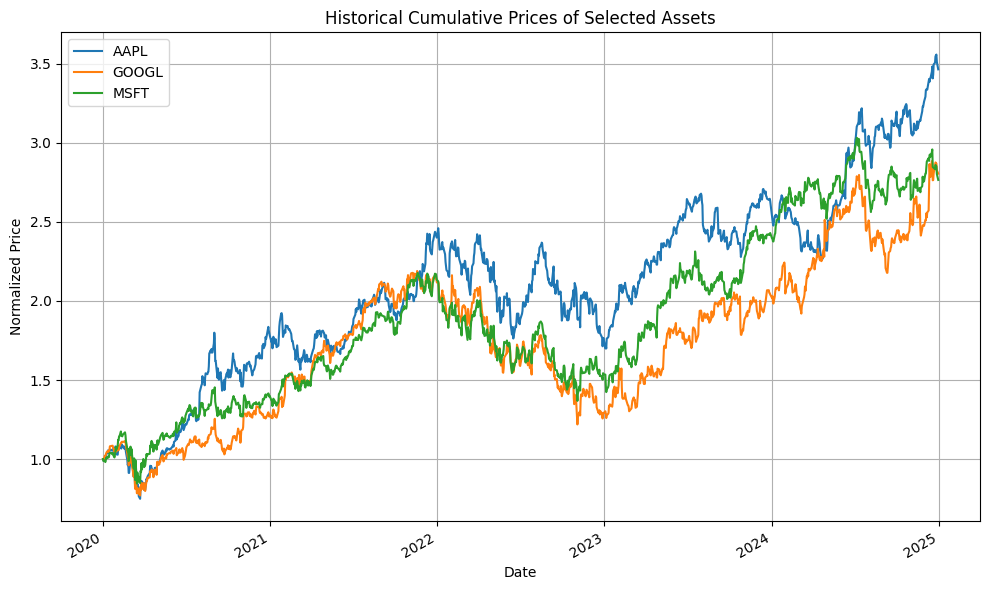

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


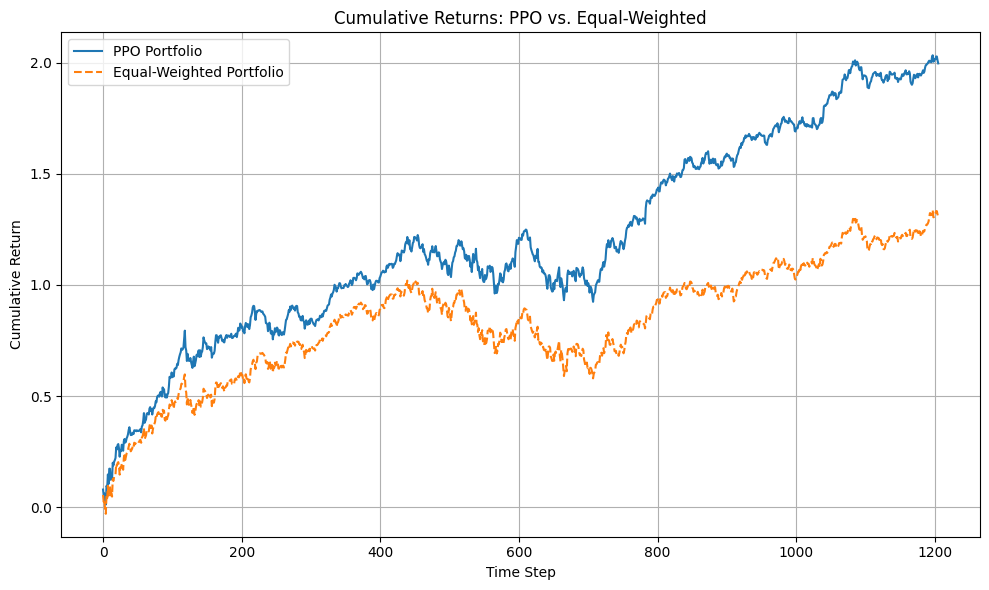

=== PPO Portfolio ===
Total Return: 1.9969
Average Daily Return: 0.001656
Standard Deviation: 0.017156
Sharpe Ratio: 0.0965

=== Equal-Weighted Portfolio ===
Total Return: 1.305
Average Daily Return: 0.001082
Standard Deviation: 0.016509
Sharpe Ratio: 0.0655


In [22]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Define tickers and date range
tickers = ['AAPL', 'MSFT', 'GOOGL']
start_date = '2020-01-01'
end_date = '2024-12-31'

# Download historical close prices
price_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Calculate daily log returns
log_returns = np.log(price_data / price_data.shift(1)).dropna()
n_assets = log_returns.shape[1]

# Plot cumulative prices (normalized to 1)
(price_data / price_data.iloc[0]).plot(figsize=(10, 6))
plt.title("Historical Cumulative Prices of Selected Assets")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(True)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Define custom Gym environment
class PortfolioEnv(gym.Env):
    def __init__(self, data, window_size=50):
        super().__init__()
        self.data = data
        self.window_size = window_size
        self.n_assets = data.shape[1]
        self.max_steps = len(data) - window_size
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(window_size, self.n_assets), dtype=np.float32)
        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets,), dtype=np.float32)

    def reset(self):
        self.current_step = 0
        return self._get_observation()

    def _get_observation(self):
        return self.data.iloc[self.current_step:self.current_step + self.window_size].values

    def step(self, action):
        action = np.clip(action, 0, 1)
        action_sum = np.sum(action)
        if action_sum == 0:
            action = np.ones(self.n_assets) / self.n_assets
        else:
            action /= action_sum

        next_return = self.data.iloc[self.current_step + self.window_size].values
        portfolio_return = np.dot(action, next_return)

        self.current_step += 1
        done = self.current_step >= self.max_steps
        next_obs = self._get_observation() if not done else np.zeros_like(self._get_observation())

        return next_obs, portfolio_return, done, {}

    def render(self, mode='human'):
        pass

# Initialize environment and PPO model
env = DummyVecEnv([lambda: PortfolioEnv(log_returns)])
model = PPO("MlpPolicy", env, verbose=0)
model.learn(total_timesteps=10000)

# Evaluate PPO and Equal-Weighted portfolios
obs = env.reset()
ppo_returns = []
equal_weight_returns = []

for i in range(env.envs[0].max_steps):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _ = env.step(action)
    ppo_returns.append(reward[0])

    equal_weights = np.ones(n_assets) / n_assets
    benchmark_return = np.dot(equal_weights, log_returns.iloc[i + env.envs[0].window_size])
    equal_weight_returns.append(benchmark_return)

    if done:
        break

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(ppo_returns), label="PPO Portfolio")
plt.plot(np.cumsum(equal_weight_returns), label="Equal-Weighted Portfolio", linestyle='--')
plt.title("Cumulative Returns: PPO vs. Equal-Weighted")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary stats
print("=== PPO Portfolio ===")
print("Total Return:", np.round(np.sum(ppo_returns), 4))
print("Average Daily Return:", np.round(np.mean(ppo_returns), 6))
print("Standard Deviation:", np.round(np.std(ppo_returns), 6))
print("Sharpe Ratio:", np.round(np.mean(ppo_returns) / (np.std(ppo_returns) + 1e-8), 4))

print("\n=== Equal-Weighted Portfolio ===")
print("Total Return:", np.round(np.sum(equal_weight_returns), 4))
print("Average Daily Return:", np.round(np.mean(equal_weight_returns), 6))
print("Standard Deviation:", np.round(np.std(equal_weight_returns), 6))
print("Sharpe Ratio:", np.round(np.mean(equal_weight_returns) / (np.std(equal_weight_returns) + 1e-8), 4))